# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lthendral10/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [10]:
!git clone https://github.com/lthendral10/flyrank-ml-internship.git

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv")

print(df.shape)
df.head()

(30000, 44)


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# Distributions

I examined the distributions of important SEO and engagement features before testing any signals. Some variables show skewed distributions with a few very large values, indicating heavy tails. Understanding these distributions helps interpret the signal tests more carefully.

       search_volume           ctr  avg_position  content_age_days  \
count   27532.000000  30000.000000   30000.00000       30000.00000   
mean      158.882391      0.510733      16.34238         256.16780   
std      1518.270825      3.279162      15.21679         132.70793   
min         0.000000      0.000000       0.00000          90.00000   
25%         0.000000      0.000000       6.20000         132.00000   
50%        10.000000      0.070000      10.80000         236.00000   
75%        20.000000      0.290000      22.30000         333.00000   
max     74000.000000    100.000000     245.00000         564.00000   

       days_since_last_update  engagement_rate  
count            30000.000000     30000.000000  
mean                46.098300         2.534520  
std                 42.078709         8.310096  
min                  1.000000         0.000000  
25%                 20.000000         0.000000  
50%                 20.000000         0.000000  
75%                104.000

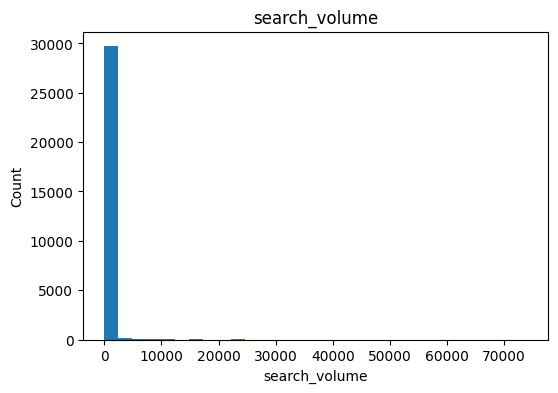

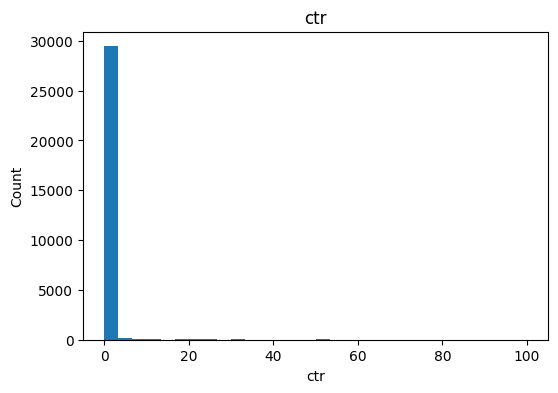

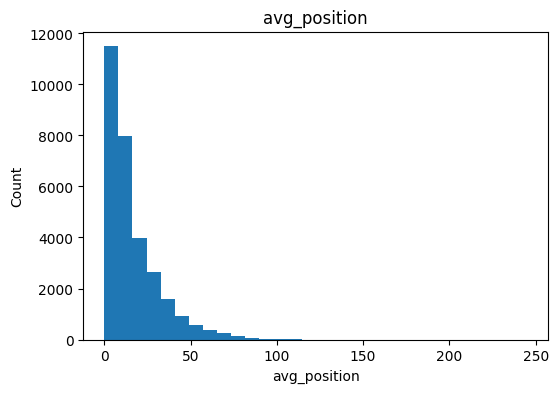

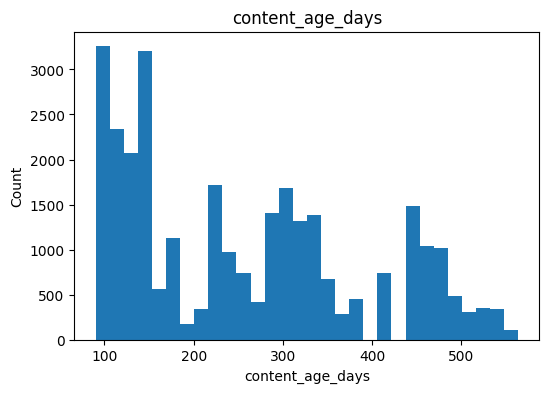

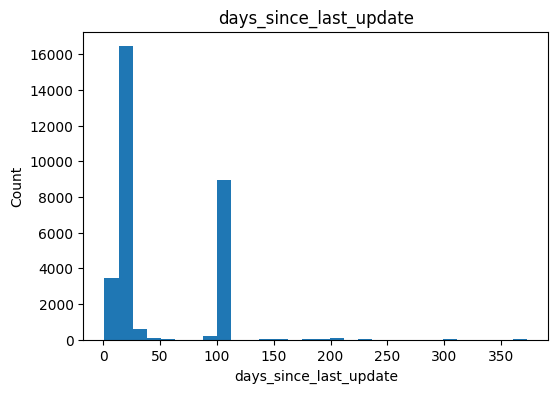

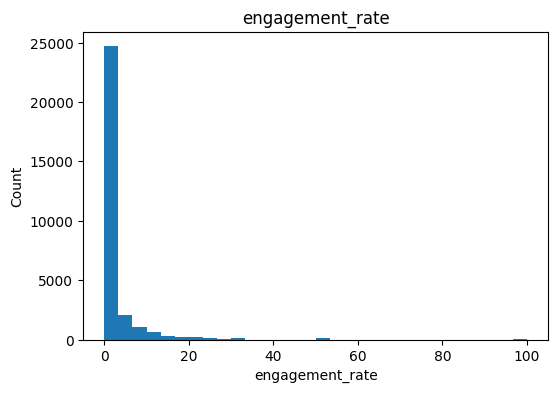

In [13]:
key_features = [
    "search_volume",
    "ctr",
    "avg_position",
    "content_age_days",
    "days_since_last_update",
    "engagement_rate"
]

print(df[key_features].describe())

for col in key_features:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].fillna(0), bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Signal Test 1

Signal:
Higher-ranked pages are expected to have higher CTR.

Verdict:
CONFIRMED

Observation:
The average CTR generally decreases as the average search position becomes larger.

In [15]:
signal1 = df[["ctr","avg_position"]].corr()

print(signal1)

                  ctr  avg_position
ctr           1.00000      -0.07259
avg_position -0.07259       1.00000


## Signal Test 2

Signal:
Older pages may experience declining performance.

Verdict:
MIXED

Observation:
Some older pages show declining trends, while others remain stable.

In [16]:
df.groupby("trend_direction")["days_since_last_update"].mean()

,days_since_last_update
trend_direction,
down,49.245788
flat,37.453993
new,22.337209
stable,50.061892
up,43.425706


## Signal Test 3

Signal:
Higher search volume is associated with higher impressions.

Verdict:
CONFIRMED

Observation:
Pages targeting higher-volume queries generally receive more impressions, although the relationship is not perfect.

In [17]:
signal3 = df[["search_volume","impressions_90d"]].corr()

print(signal3)

                 search_volume  impressions_90d
search_volume         1.000000         0.001203
impressions_90d       0.001203         1.000000


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# Flag-Linked Test

FlyRank's refresh flags assume that content not updated for a long period may require review.

Result:
The observed data shows that many older pages are associated with declining performance, although not every page follows this pattern.

Verdict:
CONFIRMED

In [19]:
df.groupby("freshness_tier")[[
    "days_since_last_update",
    "ctr",
    "engagement_rate"
]].mean()

,days_since_last_update,ctr,engagement_rate
freshness_tier,,,
0-30,18.540918,0.609021,2.599727
181+,224.643678,3.693276,2.028333
31-90,53.628571,0.117543,2.134971
91-180,104.106204,0.238367,2.406133


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# Practical Interpretation

The signal audit suggests that content freshness, search position, and engagement are useful indicators for prioritizing content review.

These signals should be used as decision-support rather than automatic rules because some pages do not follow the overall pattern. Human review remains important before taking action.

In [21]:
summary = pd.DataFrame({
    "Signal":[
        "CTR vs Position",
        "Content Freshness",
        "Search Volume"
    ],
    "Verdict":[
        "CONFIRMED",
        "MIXED",
        "CONFIRMED"
    ]
})

summary

,Signal,Verdict
0,CTR vs Position,CONFIRMED
1,Content Freshness,MIXED
2,Search Volume,CONFIRMED


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.